## 07_heatmap.ipynb

In [67]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [68]:
db_path = "../data/checking-logs.sqlite"
conn = sqlite3.connect(db_path)
df = pd.read_sql("SELECT * FROM checker", conn)
conn.close()

In [69]:
df = df[~df['uid'].str.startswith('admin', na=False)].copy()
df = df.dropna(subset=['uid'])

df['timestamp'] = pd.to_datetime(df['timestamp'])
df['weekday'] = df['timestamp'].dt.day_name()
df['hour'] = df['timestamp'].dt.hour
df['commits'] = 1

In [70]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

wd = (df.groupby(['uid', 'weekday'])['commits']
      .sum()
      .unstack(fill_value=0)
      .reindex(columns=day_order))

hr = (df.groupby(['uid', 'hour'])['commits']
      .sum()
      .unstack(fill_value=0)
      .reindex(columns=range(24), fill_value=0))

total = df.groupby('uid')['commits'].sum().sort_values(ascending=False)
wd = wd.loc[total.index]
hr = hr.loc[total.index]

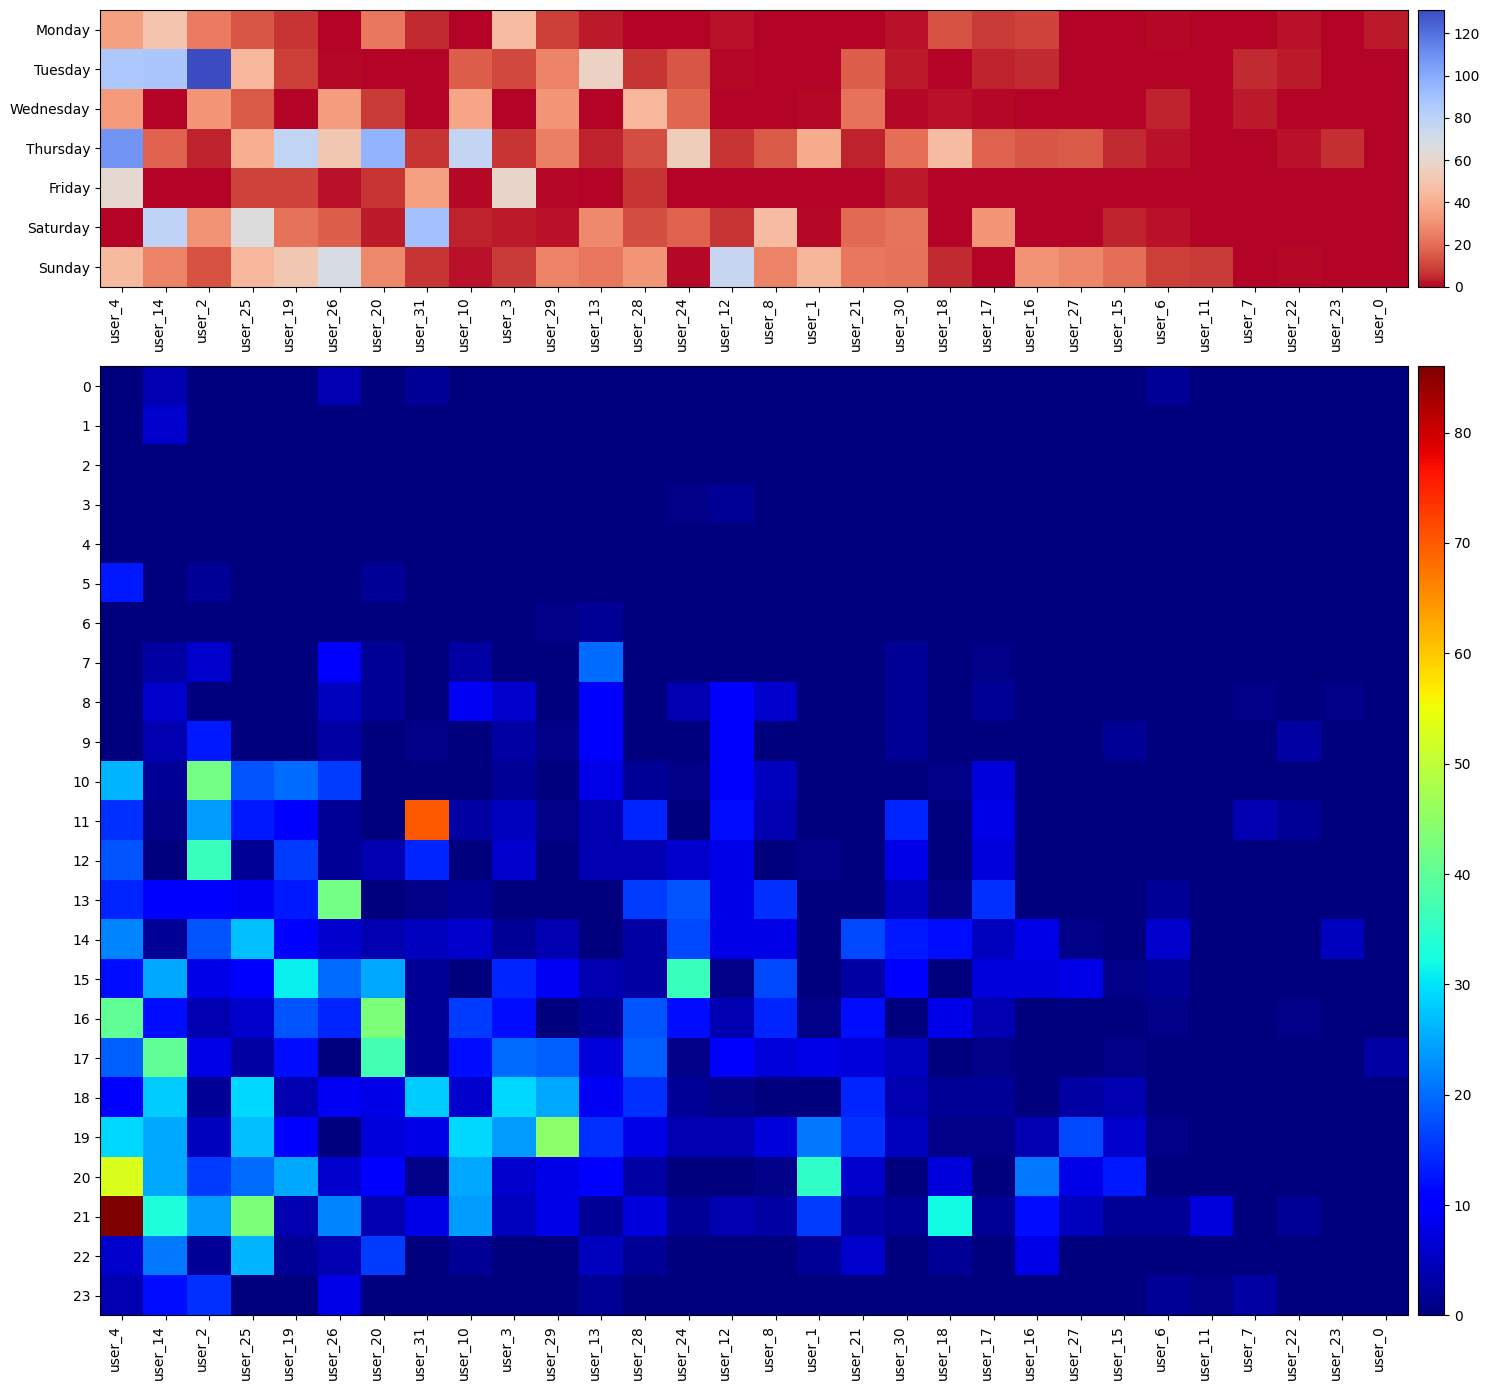

In [71]:
fig = plt.figure(figsize=(15, 14))
gs = fig.add_gridspec(2, 1, height_ratios=[7, 24])

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

im1 = ax1.imshow(wd.T, cmap='coolwarm_r', aspect='auto')
ax1.set_xticks(range(len(wd)))
ax1.set_xticklabels(wd.index, rotation=90, ha='right')
ax1.set_yticks(range(7))
ax1.set_yticklabels(wd.columns)

divider1 = make_axes_locatable(ax1)
cax1 = divider1.append_axes("right", size="2%", pad=0.1)
plt.colorbar(im1, cax=cax1)

im2 = ax2.imshow(hr.T, cmap='jet', aspect='auto')
ax2.set_xticks(range(len(hr)))
ax2.set_xticklabels(hr.index, rotation=90, ha='right')
ax2.set_yticks(range(24))
ax2.set_yticklabels(range(24))

divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes("right", size="2%", pad=0.1)
plt.colorbar(im2, cax=cax2)

plt.tight_layout()
plt.show()

## "Which user has the most commits on Tuesday?" The answer is user_*.

## user_2

## "Which user has the most commits on Thursday?" The answer is user_*.

## user_4

## "On which weekday do users not like to make a lot of commits?" The answer, for example, is Monday.

## Friday

## "Which user made the largest number of commits at which hour?" The answer is user_1, 15.

## user_4, 21